In [2]:
from src.fxlms import FxLMS
import soundfile as sf
import numpy as np
from scipy.io import loadmat

In [3]:
ir = loadmat('data/panel_ir_clean.mat')
ir.keys()

dict_keys(['__header__', '__version__', '__globals__', 'panel_ir'])

In [4]:
panel_ir = ir['panel_ir'].squeeze()
panel_ir.shape

(128,)

In [5]:
wav, sr = sf.read('audio_experiments/mics_nc.wav')
wav.shape

(240640, 2)

In [6]:
target = wav[:, 0]
ref = wav[:, 1]

ref.shape, target.shape

((240640,), (240640,))

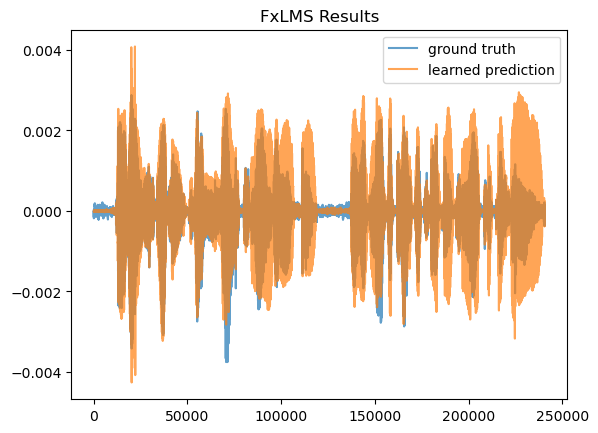

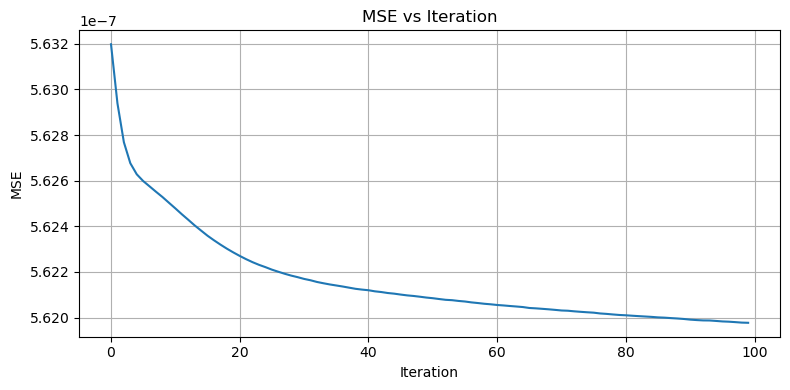

In [7]:
# NLMS update
fx = FxLMS(ref, target, panel_ir, filter_order=256, step_fn=0.1)
fx.learn(n_iter = 100)

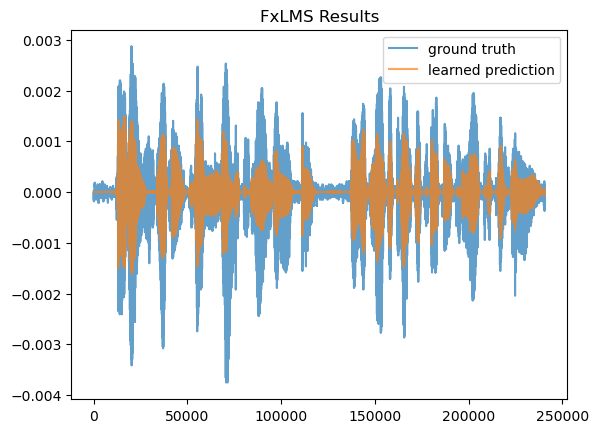

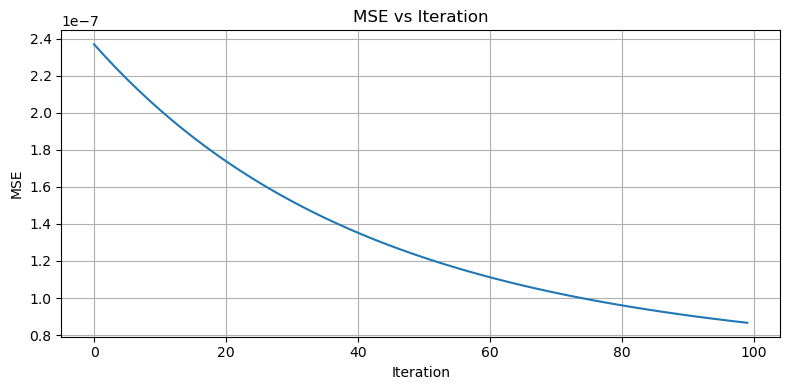

In [8]:
# LMS update
fx = FxLMS(ref, target, panel_ir, filter_order=256, step_fn=0.1, use_norm=False)
fx.learn(n_iter = 100)

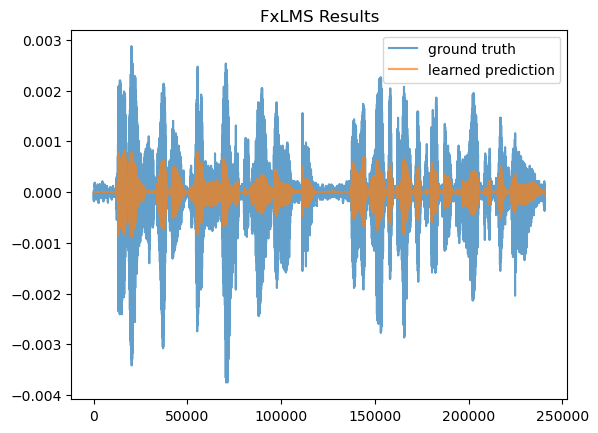

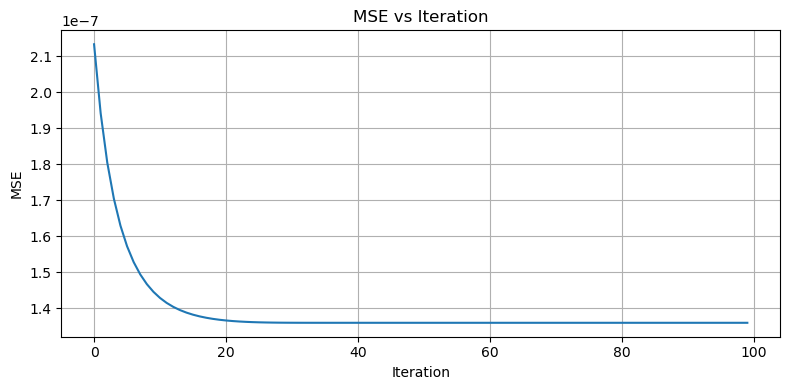

In [9]:
# Scheduler
step_fn = lambda t: max(1e-5, 0.9 * np.exp(-t / 5))
fx = FxLMS(ref, target, panel_ir, filter_order=256, step_fn=step_fn, use_norm=False)
fx.learn(n_iter = 100)